# Day 8 ? Label taxonomy and leakage audit

This notebook audits the existing MIT-BIH label pipeline and the Day 4 split. It reads the locally downloaded annotations and saved derived shards, checks counts/mappings, and writes Day 8 audit tables and one new figure. It does not modify raw inputs, relabel data, retrain the CNN, or alter Day 6 evaluation outputs.

The phrase **eight supported test classes** means the eight original model labels with at least one positive test example. There is no separate eight-class merged taxonomy in the current code or checkpoint.

In [1]:
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import html
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
while not (ROOT / 'configs' / 'preprocessing' / 'mitbih_v1.json').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'configs' / 'preprocessing' / 'mitbih_v1.json').exists(), 'Run this notebook from the repository.'
RAW = ROOT / 'data' / 'raw' / 'mitbih'
SPLITS = ROOT / 'data' / 'splits' / 'mitbih_v1'
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
for required in [RAW / 'RECORDS', SPLITS / 'split_metadata.json', TABLES / 'mitbih_all_annotation_symbol_counts.csv']:
    assert required.exists(), f'Missing local audit input: {required}'

config = json.loads((ROOT / 'configs' / 'preprocessing' / 'mitbih_v1.json').read_text(encoding='utf-8'))
label_config = config['labels']
beat_map = label_config['beat_symbols']
nonbeat_symbols = set(label_config['nonbeat_symbols'])
class_names = sorted(set(beat_map.values()))
class_to_index = {name: index for index, name in enumerate(class_names)}
split_metadata = json.loads((SPLITS / 'split_metadata.json').read_text(encoding='utf-8'))
print(f'Repository: {ROOT}')
print(f'Raw record count: {len((RAW / "RECORDS").read_text().splitlines())}; model outputs: {len(class_names)}')
print('Model class order:', class_names)

Repository: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout
Raw record count: 48; model outputs: 15
Model class order: ['/', 'A', 'E', 'F', 'J', 'L', 'N', 'Q', 'R', 'S', 'V', 'a', 'e', 'f', 'j']


## 1. Raw annotation symbols and current label mapping

The next cell recounts all `.atr` symbols from the local raw records through WFDB and compares them with the Day 2 generated count table. Beat symbols retain their symbols. Event/marker symbols are excluded by the configured beat-window pipeline, with no model class assigned. Boundary-truncated beat windows are accounted for separately.

In [2]:
raw_symbols = Counter()
record_ids = [line.strip() for line in (RAW / 'RECORDS').read_text().splitlines() if line.strip()]
for record_id in record_ids:
    ann = wfdb.rdann(str(RAW / record_id), 'atr')
    raw_symbols.update(ann.symbol)

source_table = pd.read_csv(TABLES / 'mitbih_all_annotation_symbol_counts.csv')
source_counts = dict(zip(source_table['symbol'].astype(str), source_table['count'].astype(int)))
assert dict(raw_symbols) == source_counts, 'Local raw annotation recount differs from Day 2 output.'
assert set(raw_symbols) == set(beat_map) | nonbeat_symbols
assert not (set(beat_map) & nonbeat_symbols)

split_counts = {name: Counter() for name in ['train', 'validation', 'test']}
label_groups = defaultdict(set)
label_records = defaultdict(set)
for split_name in split_counts:
    shard_paths = sorted((SPLITS / split_name).glob('*.npz'))
    assert shard_paths, f'No shards found for {split_name}'
    for shard in shard_paths:
        with np.load(shard, allow_pickle=False) as data:
            labels = data['labels'].astype(str)
            symbols = data['source_symbols'].astype(str)
            records = data['record_ids'].astype(str)
            groups = data['patient_groups'].astype(str)
            assert len(labels) == len(symbols) == len(records) == len(groups)
            assert np.array_equal(labels, symbols), f'Label/source-symbol mismatch in {shard.name}'
            assert set(labels) <= set(class_names), f'Invalid labels in {shard.name}'
            assert set(records) == {shard.stem}, f'Record provenance mismatch in {shard.name}'
            split_counts[split_name].update(labels.tolist())
            for label in np.unique(labels):
                mask = labels == label
                label_groups[label].update(groups[mask].tolist())
                label_records[label].update(records[mask].tolist())

processed_counts = Counter()
for counter in split_counts.values():
    processed_counts.update(counter)
raw_description = dict(zip(source_table['symbol'].astype(str), source_table['source_description'].astype(str)))
raw_group = dict(zip(source_table['symbol'].astype(str), source_table['annotation_group'].astype(str)))
rows = []
for symbol in sorted(raw_symbols):
    if symbol in beat_map:
        label = beat_map[symbol]
        rows.append({
            'source_symbol': symbol, 'source_description': raw_description[symbol],
            'raw_count': int(raw_symbols[symbol]), 'annotation_type': 'beat',
            'preprocessing_label': label, 'processed_count': int(processed_counts[label]),
            'boundary_dropped': int(raw_symbols[symbol] - processed_counts[label]),
            'model_class_name': label, 'model_class_index': class_to_index[label],
            'handling': 'Identity mapping; one model class retained'
        })
    else:
        rows.append({
            'source_symbol': symbol, 'source_description': raw_description[symbol],
            'raw_count': int(raw_symbols[symbol]), 'annotation_type': 'non-beat/event',
            'preprocessing_label': '', 'processed_count': 0, 'boundary_dropped': 0,
            'model_class_name': '', 'model_class_index': '',
            'handling': 'Excluded from beat windows as event/marker; no model class'
        })
label_pipeline = pd.DataFrame(rows)
assert int(label_pipeline.loc[label_pipeline.annotation_type == 'beat', 'boundary_dropped'].sum()) == 34
assert int(label_pipeline.loc[label_pipeline.annotation_type != 'beat', 'raw_count'].sum()) == 3153
assert int(label_pipeline.loc[label_pipeline.annotation_type == 'beat', 'processed_count'].sum()) == sum(sum(counter.values()) for counter in split_counts.values()) == 109460
label_pipeline.to_csv(TABLES / 'day8_label_pipeline_counts.csv', index=False)
raw_table = label_pipeline[['source_symbol','source_description','annotation_type','raw_count']].copy()
raw_table.to_csv(TABLES / 'day8_raw_annotation_symbols.csv', index=False)
display(label_pipeline)
print('Raw annotation total:', int(label_pipeline.raw_count.sum()))
print('Processed beat-segment total:', int(label_pipeline.processed_count.sum()))

,source_symbol,source_description,raw_count,annotation_type,preprocessing_label,processed_count,boundary_dropped,model_class_name,model_class_index,handling
0,!,Ventricular flutter wave,472,non-beat/event,,0,0,,,Excluded from beat windows as event/marker; no...
1,"""",Comment annotation,437,non-beat/event,,0,0,,,Excluded from beat windows as event/marker; no...
2,+,Rhythm change marker; rhythm label is carried ...,1291,non-beat/event,,0,0,,,Excluded from beat windows as event/marker; no...
3,/,Paced beat,7028,beat,/,7027,1,/,0,Identity mapping; one model class retained
4,A,Atrial premature beat,2546,beat,A,2546,0,A,1,Identity mapping; one model class retained
5,E,Ventricular escape beat,106,beat,E,106,0,E,2,Identity mapping; one model class retained
6,F,Fusion of ventricular and normal beat,803,beat,F,802,1,F,3,Identity mapping; one model class retained
7,J,Nodal (junctional) premature beat,83,beat,J,83,0,J,4,Identity mapping; one model class retained
8,L,Left bundle branch block beat,8075,beat,L,8072,3,L,5,Identity mapping; one model class retained
9,N,Normal beat,75052,beat,N,75028,24,N,6,Identity mapping; one model class retained


Raw annotation total: 112647
Processed beat-segment total: 109460


## 2. Split distributions and test-supported labels

All three split distributions below retain all 15 configured source-symbol classes, including explicit zeroes. The eight-row table is a support view of the existing 15-output model: it includes only labels having at least one positive test sample and does not merge or rename classes.

In [3]:
distribution_rows = []
for label in class_names:
    distribution_rows.append({
        'label': label, 'model_class_index': class_to_index[label],
        'processed_total': int(processed_counts[label]),
        'train': int(split_counts['train'][label]),
        'validation': int(split_counts['validation'][label]),
        'test': int(split_counts['test'][label]),
        'records_with_label': len(label_records[label]),
        'groups_with_label': len(label_groups[label]),
    })
distribution = pd.DataFrame(distribution_rows)
assert (distribution[['train','validation','test']].sum(axis=1) == distribution['processed_total']).all()
assert int(distribution['processed_total'].sum()) == int(split_metadata['total_segments'])
for split_name in ['train','validation','test']:
    assert int(distribution[split_name].sum()) == int(split_metadata['splits'][split_name]['segment_count'])
    assert {r['label']: r[split_name] for r in distribution_rows if r[split_name]} == split_metadata['splits'][split_name]['class_distribution']
distribution.to_csv(TABLES / 'day8_split_class_distribution.csv', index=False)
supported_test = distribution.loc[distribution['test'] > 0].copy()
unsupported_test = distribution.loc[distribution['test'] == 0].copy()
assert len(supported_test) == 8 and len(unsupported_test) == 7
supported_test.to_csv(TABLES / 'day8_test_supported_8_class_distribution.csv', index=False)
distribution.to_csv(TABLES / 'day8_processed_15_class_distribution.csv', index=False)
display(Markdown('### All 15 configured labels'))
display(distribution)
display(Markdown('### The 8 original labels with positive test support (not a new 8-class taxonomy)'))
display(supported_test[['label','processed_total','train','validation','test','records_with_label','groups_with_label']])
display(Markdown('### Seven labels with no positive test support'))
display(unsupported_test[['label','processed_total','train','validation','test','records_with_label','groups_with_label']])

### All 15 configured labels

,label,model_class_index,processed_total,train,validation,test,records_with_label,groups_with_label
0,/,0,7027,3407,1542,2078,4,4
1,A,1,2546,2418,78,50,27,26
2,E,2,106,106,0,0,2,2
3,F,3,802,782,7,13,17,16
4,J,4,83,80,3,0,5,5
5,L,5,8072,3948,2123,2001,4,4
6,N,6,75028,53489,11342,10197,40,39
7,Q,7,33,29,0,4,6,6
8,R,8,7255,7255,0,0,6,6
9,S,9,2,2,0,0,1,1


### The 8 original labels with positive test support (not a new 8-class taxonomy)

,label,processed_total,train,validation,test,records_with_label,groups_with_label
0,/,7027,3407,1542,2078,4,4
1,A,2546,2418,78,50,27,26
3,F,802,782,7,13,17,16
5,L,8072,3948,2123,2001,4,4
6,N,75028,53489,11342,10197,40,39
7,Q,33,29,0,4,6,6
10,V,7129,5049,870,1210,37,36
11,a,150,28,116,6,7,6


### Seven labels with no positive test support

,label,processed_total,train,validation,test,records_with_label,groups_with_label
2,E,106,106,0,0,2,2
4,J,83,80,3,0,5,5
8,R,7255,7255,0,0,6,6
9,S,2,2,0,0,1,1
12,e,16,16,0,0,1,1
13,f,982,722,260,0,3,3
14,j,229,219,10,0,5,5


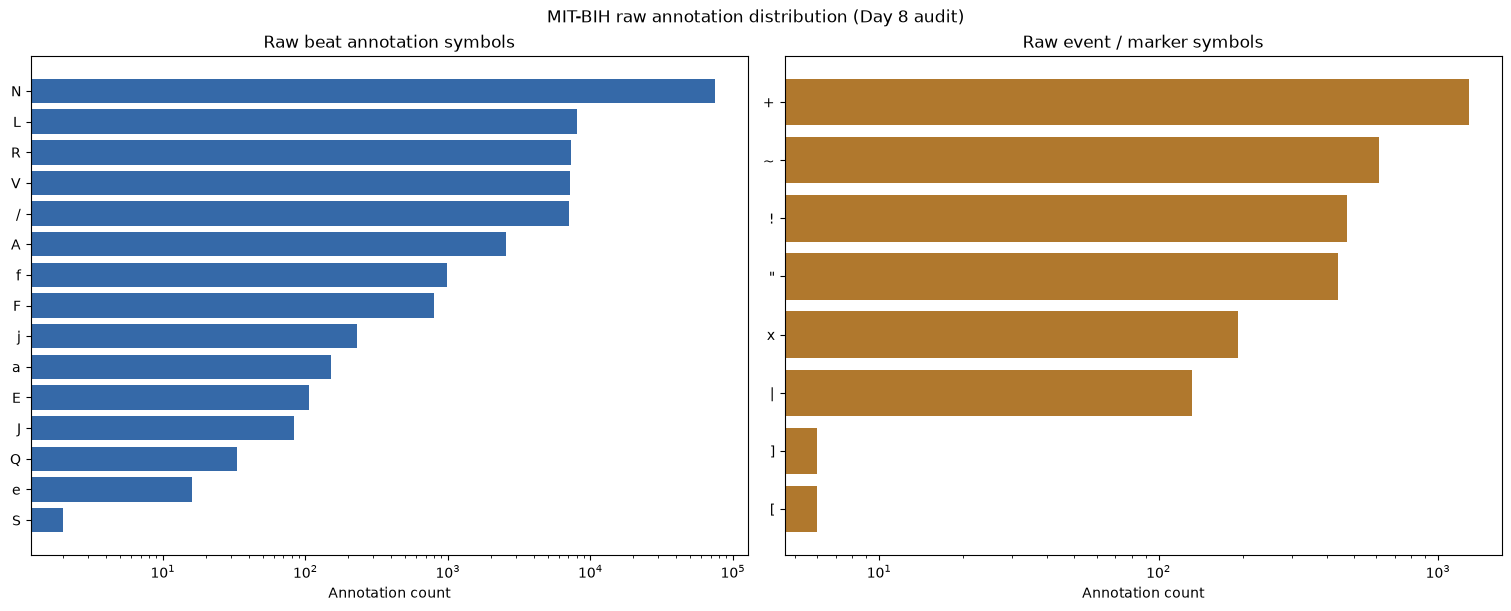

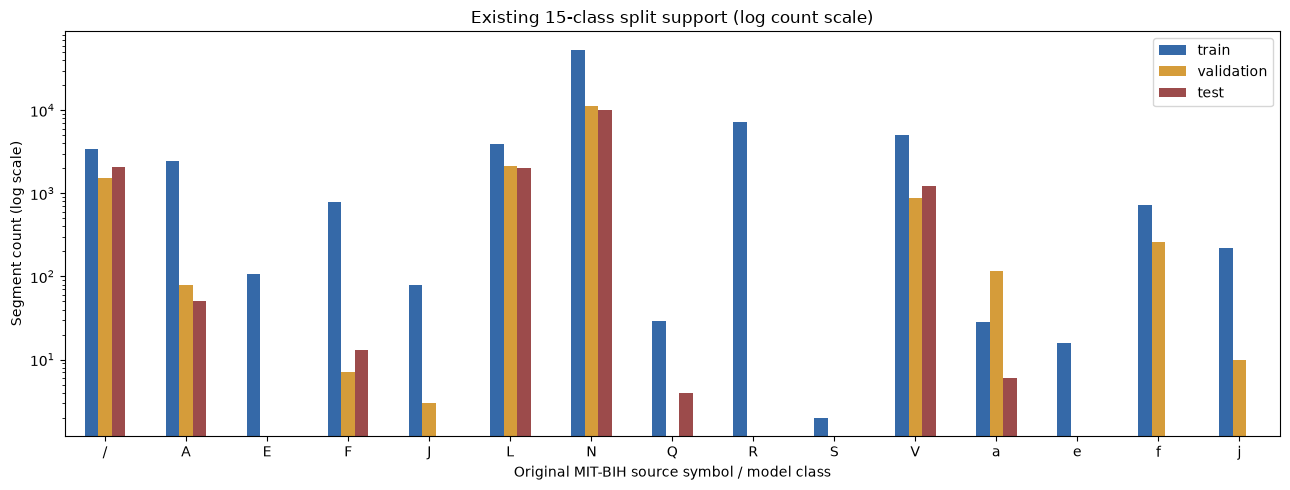

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
beat_rows = label_pipeline[label_pipeline.annotation_type == 'beat'].sort_values('raw_count')
event_rows = label_pipeline[label_pipeline.annotation_type != 'beat'].sort_values('raw_count')
axes[0].barh(beat_rows.source_symbol, beat_rows.raw_count, color='#3569a8')
axes[0].set_title('Raw beat annotation symbols')
axes[0].set_xlabel('Annotation count')
axes[0].set_xscale('log')
axes[1].barh(event_rows.source_symbol, event_rows.raw_count, color='#b0782d')
axes[1].set_title('Raw event / marker symbols')
axes[1].set_xlabel('Annotation count')
axes[1].set_xscale('log')
fig.suptitle('MIT-BIH raw annotation distribution (Day 8 audit)')
fig.savefig(FIGURES / 'mitbih_label_leakage_audit.png', dpi=200)
plt.show()

ax = distribution.set_index('label')[['train','validation','test']].plot(
    kind='bar', figsize=(13, 5), logy=True, color=['#3569a8','#d59c3a','#9c4b4b'])
ax.set_title('Existing 15-class split support (log count scale)')
ax.set_xlabel('Original MIT-BIH source symbol / model class')
ax.set_ylabel('Segment count (log scale)')
ax.tick_params(axis='x', rotation=0)
ax.figure.tight_layout()
ax.figure.savefig(FIGURES / 'mitbih_split_class_support_audit.png', dpi=200)
plt.show()

## 3. Patient/record grouping and leakage checks

The local PhysioNet documentation (`data/raw/mitbih/mitdbdir/intro.htm`) reports 48 records from 47 subjects and explicitly states that records 201 and 202 came from the same male subject. It does not provide a unique named subject ID for each record. Under those published counts, the known 201/202 pair accounts for the single duplicate subject relationship; the remaining 46 records therefore form 46 other subject-equivalence groups. This is an inference about grouping from the dataset's complete record/subject count plus the explicit pair, not an invented patient identifier.

The next cell compares that evidence with the actual split assignment and checks for cross-split record/group overlaps.

In [5]:
records_doc = (RAW / 'mitdbdir' / 'intro.htm').read_text(encoding='latin-1', errors='replace')
plain_doc = html.unescape(re.sub(r'<[^>]+>', ' ', records_doc))
plain_doc = re.sub(r'\s+', ' ', plain_doc)
assert '25 men aged 32 to 89 years, and 22 women aged 23 to 89 years' in plain_doc
assert 'Records 201 and 202 came from the same male subject' in plain_doc
assert split_metadata['total_records'] == 48 and split_metadata['total_groups'] == 47
assignment = {}
record_to_group = {}
for split_name, split_info in split_metadata['splits'].items():
    for group in split_info['groups']:
        assert group not in assignment
        assignment[group] = split_name
    for record in split_info['records']:
        assert record not in record_to_group
        record_to_group[record] = split_name
assert record_to_group['201'] == record_to_group['202']
assert len(assignment) == 47 and len(record_to_group) == 48
for key, check in split_metadata['overlap_checks'].items():
    assert not check['record_ids'] and not check['group_ids'], key
assert split_metadata['validation']['duplicate_content_across_splits'] is False
assert split_metadata['validation']['duplicate_provenance_across_splits'] is False
print('Source documentation: 48 records, 47 subjects; records 201/202 explicitly same subject.')
print('Inference: that known pair accounts for the one-record excess; 46 remaining records are singleton subject groups.')
print('Current split: 47 pseudonymous groups assigned once; 201/202 are together in', record_to_group['201'])
print('Pairwise record/group overlaps: none; duplicate signal+label and provenance checks: passed.')
print('No named patient ID was created or inferred.')

presence = distribution[['label','processed_total','records_with_label','groups_with_label','train','validation','test']].copy()
presence.to_csv(TABLES / 'day8_class_group_support.csv', index=False)
display(presence.sort_values(['groups_with_label','processed_total']))

Source documentation: 48 records, 47 subjects; records 201/202 explicitly same subject.
Inference: that known pair accounts for the one-record excess; 46 remaining records are singleton subject groups.
Current split: 47 pseudonymous groups assigned once; 201/202 are together in validation
Pairwise record/group overlaps: none; duplicate signal+label and provenance checks: passed.
No named patient ID was created or inferred.


,label,processed_total,records_with_label,groups_with_label,train,validation,test
9,S,2,1,1,2,0,0
12,e,16,1,1,16,0,0
2,E,106,2,2,106,0,0
13,f,982,3,3,722,260,0
0,/,7027,4,4,3407,1542,2078
5,L,8072,4,4,3948,2123,2001
4,J,83,5,5,80,3,0
14,j,229,5,5,219,10,0
7,Q,33,6,6,29,0,4
11,a,150,7,6,28,116,6


## 4. Baseline review and audit conclusions

The Day 6 CNN remains an unchanged 15-output source-symbol baseline. Eight classes have positive test support; the other seven were not merged or removed, and their test sensitivity/AUROC cannot be estimated. Accuracy (0.7688) is dominated by `N`, while macro-F1 is 0.1399; supported `A`, `F`, `L`, `Q`, and `a` each have zero F1. This audit does not justify changing labels to improve those scores.

The current taxonomy is transparent as a source-symbol mapping but has not been justified as the final research target. Retain it as a reproducible exploratory baseline. Any alternative should be specified from the research question and literature, preserve a documented source-to-target crosswalk, and be versioned before a future training run. Do not retrain in this notebook.

The current split is record-disjoint and, given the local official record/subject count and known shared-subject pair, its 47 group assignments support patient-equivalence separation. However, seven labels are absent from test and five from validation. Several rare classes occur in too few record groups for all three-way evaluation (`S` and `e` each occur in one group; `E` in two). A changed split cannot manufacture independent patients for these labels. Any protocol revision must be decided before another model run and must report unsupported classes explicitly.